In [6]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_p_dist_custom, simulate_pulses_single_atom, p_shift_random_walk, simulate_optical_pumping
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFE_seq, RR3_gate
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, display_table, display_table_compare
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg, kb
import matplotlib.pyplot as plt

In [ ]:
N = 10000
Temp = 10e-6

cycles = 8

rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
# initial_state[15] = 1
initial_state[16] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

moms_list = []
fracs_list = []

moms, fracs, mom_grid, frac_grid, _ = simulate_pulses_p_dist(pulse_seq=RR3, Temp=Temp, no_atoms=N, basis=basis, initial_state=initial_state)
moms = moms/(hbar*k_eff)

moms_list.append(moms)
fracs_list.append(fracs[-1])

moms = simulate_optical_pumping(basis=basis, init_mom_dist_grid=mom_grid, state_fracs_grid=frac_grid[-1,:,:])
moms = moms/(hbar*k_eff)

moms_list.append(moms)
fracs_list.append(np.ones(len(moms)))

for i in range(cycles-1):
    moms, fracs, mom_grid, frac_grid = simulate_pulses_p_dist_custom(pulse_seq=RR3, init_mom_dist=moms*hbar*k_eff, basis=basis, initial_state=initial_state)
    moms = moms/(hbar*k_eff)

    moms_list.append(moms)
    fracs_list.append(fracs[-1])

    moms = simulate_optical_pumping(basis=basis, init_mom_dist_grid=mom_grid, state_fracs_grid=frac_grid[-1,:,:])
    moms = moms/(hbar*k_eff)

    moms_list.append(moms)
    fracs_list.append(np.ones(len(moms)))

# fig1, ax1 = plt.subplots(figsize=(6, 7.5), layout= 'constrained')

# plot_hist(ax= ax1, mom_vals= moms, fracs= fracs, n_bins= 100, n_atoms= N, temp=Temp)

# xlims = np.arange(-10,11)
# ax1.set_xticks(xlims)
# ax1.set_xlim(-10,10)

# # fig1.tight_layout
# plt.show()

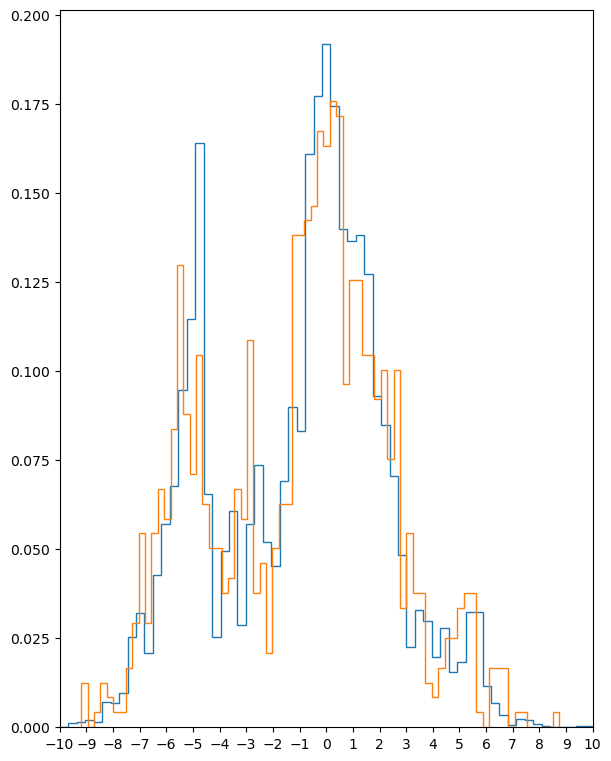

In [26]:
fig1, ax1 = plt.subplots(figsize=(6, 7.5), layout= 'constrained')


ax1.hist(x= moms_list[0], weights= fracs_list[0], bins = 150, histtype='step', density=True)
ax1.hist(x= moms_list[1], weights= fracs_list[1], bins = 75, histtype='step', density=True)

xlims = np.arange(-10,11)
ax1.set_xticks(xlims)
ax1.set_xlim(-10,10)

# fig1.tight_layout
plt.show()

In [20]:
np.shape(fracs_list[1])

(1000,)